# H-QNN v1 — Benchmark Bernini
## ResNet-50 (frozen) → FC → PQC → Classificador Linear

**Setup idêntico ao Bernini** — apenas o classificador final é trocado (RF → PQC):
- ResNet-50 **completamente congelada** (igual ao Bernini)
- Split: 10% por classe como validação (estratificado)
- Adam lr=1e-3 | Early stopping patience=30 | Max 100 épocas
- **Sem** label smoothing | **Sem** cosine annealing | **Sem** TTA
- N_QUBITS=8, N_LAYERS=5, BasicEntanglerLayers (RX)

Permite comparação direta com ResNet50+RF do Bernini (melhor baseline, 4 classes).

In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import pennylane as qml
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import time
from torchvision import transforms, models, datasets
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              balanced_accuracy_score, confusion_matrix)

plt.rcParams['figure.dpi'] = 120

In [5]:
# ── Configuração Global ───────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

N_QUBITS        = 8
N_LAYERS        = 5
NUM_EPOCHS      = 100
BATCH_SIZE      = 32
PATIENCE        = 15
IMGS_PATH       = '../datasets/rats/dataset'
CHECKPOINT_PATH = 'best_model_v1.pt'

LABEL_PT = {'warm-up': 'Baixo', 'moderate': 'Moderado', 'heavy': 'Intenso', 'severe': 'Severo'}

In [6]:
# ── Transforms ────────────────────────────────────────────────────────────────
transform_treino = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
transform_eval = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# ── Split idêntico ao Bernini: 10% por classe como validação ──────────────────
full_train_aug  = datasets.ImageFolder(root=f'{IMGS_PATH}/train', transform=transform_treino)
full_train_eval = datasets.ImageFolder(root=f'{IMGS_PATH}/train', transform=transform_eval)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=SEED)
train_idx, val_idx = next(sss.split(range(len(full_train_aug)), full_train_aug.targets))

train_dataset = Subset(full_train_aug,  train_idx)
val_dataset   = Subset(full_train_eval, val_idx)
test_dataset  = datasets.ImageFolder(root=f'{IMGS_PATH}/test', transform=transform_eval)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

N_CLASSES = len(full_train_aug.classes)
print(f'Dispositivo  : {DEVICE}')
print(f'Classes ({N_CLASSES}): {full_train_aug.classes}')
print(f'Treino    : {len(train_dataset)} imagens')
print(f'Validacao : {len(val_dataset)} imagens  (10% por classe — Bernini)')
print(f'Teste     : {len(test_dataset)} imagens  (rato 1)')

Dispositivo  : cuda:0
Classes (4): ['heavy', 'moderate', 'severe', 'warm-up']
Treino    : 20869 imagens
Validacao : 2319 imagens  (10% por classe — Bernini)
Teste     : 4513 imagens  (rato 1)


In [8]:
# ── Circuito Quantico (PQC) ───────────────────────────────────────────────────
dev = qml.device('default.qubit', wires=N_QUBITS)

@qml.qnode(dev, interface='torch')
def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='X')
    qml.BasicEntanglerLayers(weights, wires=range(N_QUBITS), rotation=qml.RX)
    return [qml.expval(qml.PauliZ(wires=i)) for i in range(N_QUBITS)]

In [9]:
# ── Modelo H-QNN v1 ───────────────────────────────────────────────────────────
class HybridQuantumModel(nn.Module):
    """
    ResNet-50 completamente congelada (Bernini) -> FC(2048, N_QUBITS)
    -> sigmoid*pi -> PQC (BasicEntanglerLayers RX) -> Dropout -> Linear
    """
    def __init__(self, n_classes: int, n_qubits: int, n_layers: int):
        super().__init__()
        self.resnet = models.resnet50(weights='DEFAULT')
        for param in self.resnet.parameters():
            param.requires_grad = False          # totalmente congelada
        in_features     = self.resnet.fc.in_features
        self.resnet.fc  = nn.Linear(in_features, n_qubits)
        weight_shapes   = {'weights': (n_layers, n_qubits)}
        self.qlayer     = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)
        self.dropout    = nn.Dropout(p=0.3)
        self.classifier = nn.Linear(n_qubits, n_classes)

    def _init_quantum_weights(self):
        with torch.no_grad():
            self.qlayer.weights.data = torch.randn_like(self.qlayer.weights) * 0.01

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.resnet(x)
        x = torch.sigmoid(x) * np.pi
        x = self.qlayer(x)
        x = self.dropout(x)
        x = self.classifier(x)
        return x

In [10]:
# ── Instancia, Pesos de Classe e Otimizador ───────────────────────────────────
model = HybridQuantumModel(N_CLASSES, N_QUBITS, N_LAYERS)
model._init_quantum_weights()
model = model.to(DEVICE)

# Pesos de classe (replicando Bernini: balanceado por contagem de amostras)
train_targets = [full_train_aug.targets[i] for i in train_idx]
class_counts  = np.bincount(train_targets, minlength=N_CLASSES)
class_weights = len(train_targets) / (N_CLASSES * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print('Pesos:', {cls: f'{w:.3f}' for cls, w in zip(full_train_aug.classes, class_weights.cpu())})

# Sem label smoothing (Bernini nao utilizou)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Adam lr=1e-3 para todos os parametros treinaveis (igual ao Bernini RNA)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

Pesos: {'heavy': '1.339', 'moderate': '0.650', 'severe': '18.179', 'warm-up': '0.602'}


In [11]:
# ── Loop de Treinamento ───────────────────────────────────────────────────────
def calcular_metricas(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    acc  = balanced_accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true,  y_pred, average='macro', zero_division=0)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true,  y_pred, average='macro', zero_division=0)
    return acc, f1, prec, rec

ROW_HDR = '  {:<10}  {:>8}  {:>8}  {:>8}  {:>9}  {:>8}'
ROW_VAL = '  {:<10}  {:>8.4f}  {:>8.4f}  {:>8.4f}  {:>9.4f}  {:>8.4f}'

print(f'\nTreinamento iniciado em [{DEVICE}]')
print('=' * 75)

best_val_loss    = float('inf')
patience_counter = 0
history          = {'train_loss': [], 'val_loss': []}
epoch_times      = []

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
t_train_start = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    t_ep_start = time.time()

    # ── Treino ────────────────────────────────────────────────────────────
    model.train()
    running_loss = 0.0
    y_true_t, y_pred_t = [], []
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        y_true_t.extend(labels.cpu().numpy())
        y_pred_t.extend(preds.cpu().numpy())
    train_loss = running_loss / len(train_dataset)
    tr_acc, tr_f1, tr_prec, tr_rec = calcular_metricas(y_true_t, y_pred_t)

    # ── Validacao ─────────────────────────────────────────────────────────
    model.eval()
    running_loss_v = 0.0
    y_true_v, y_pred_v = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            running_loss_v += loss.item() * inputs.size(0)
            y_true_v.extend(labels.cpu().numpy())
            y_pred_v.extend(preds.cpu().numpy())
    val_loss = running_loss_v / len(val_dataset)
    vl_acc, vl_f1, vl_prec, vl_rec = calcular_metricas(y_true_v, y_pred_v)

    # ── Historico ─────────────────────────────────────────────────────────
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    # ── Checkpoint + Early Stopping ───────────────────────────────────────
    marker = ''
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        marker = '  ✓'
    else:
        patience_counter += 1

    epoch_times.append(time.time() - t_ep_start)

    print(f'\nEpoca {epoch:>3}/{NUM_EPOCHS}  patience={patience_counter}/{PATIENCE}{marker}')
    print(ROW_HDR.format('', 'Perda', 'Ac.Bal.', 'F1', 'Precisao', 'Recall'))
    print(ROW_VAL.format('Treino',    train_loss, tr_acc, tr_f1, tr_prec, tr_rec))
    print(ROW_VAL.format('Validacao', val_loss,   vl_acc, vl_f1, vl_prec, vl_rec))

    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping ativado na epoca {epoch}.')
        break

t_train_total = time.time() - t_train_start
t_ep_mean     = np.mean(epoch_times)
vram_peak_gb  = torch.cuda.max_memory_allocated() / 1024**3 if torch.cuda.is_available() else 0.0

print(f'\nMelhor val loss       : {best_val_loss:.4f}  checkpoint: {CHECKPOINT_PATH}')
print(f'Tempo médio por época : {t_ep_mean:.1f} s')
print(f'Tempo total treino    : {t_train_total:.1f} s  ({t_train_total/60:.1f} min)')
print(f'Pico de VRAM          : {vram_peak_gb:.2f} GB  (torch.cuda.max_memory_allocated)')


Treinamento iniciado em [cuda:0]

Epoca   1/100  patience=0/15  ✓
                 Perda   Ac.Bal.        F1   Precisao    Recall
  Treino        1.1213    0.5087    0.4323     0.4329    0.5087
  Validacao     0.8143    0.7322    0.6010     0.5907    0.7322

Epoca   2/100  patience=0/15  ✓
                 Perda   Ac.Bal.        F1   Precisao    Recall
  Treino        0.7704    0.7084    0.6102     0.5769    0.7084
  Validacao     0.6566    0.7710    0.6219     0.5921    0.7710

Epoca   3/100  patience=0/15  ✓
                 Perda   Ac.Bal.        F1   Precisao    Recall
  Treino        0.6570    0.7521    0.6646     0.6297    0.7521
  Validacao     0.5323    0.8028    0.7231     0.6949    0.8028

Epoca   4/100  patience=0/15  ✓
                 Perda   Ac.Bal.        F1   Precisao    Recall
  Treino        0.6121    0.7751    0.6911     0.6542    0.7751
  Validacao     0.5105    0.8174    0.7089     0.6815    0.8174

Epoca   5/100  patience=0/15  ✓
                 Perda   Ac.Bal. 

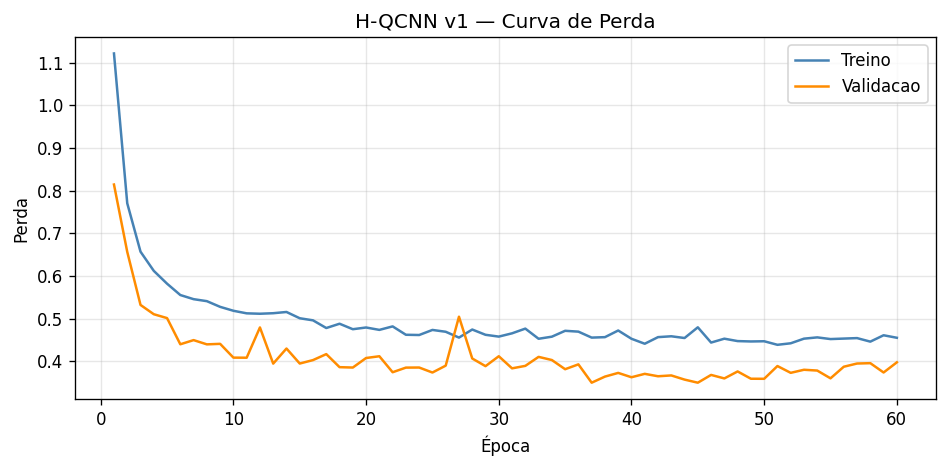

Melhor val loss: 0.3501  na epoca 45


In [27]:
# ── Curva de Perda por Época ──────────────────────────────────────────────────
epochs_ran = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs_ran, history['train_loss'], label='Treino',    color='steelblue')
plt.plot(epochs_ran, history['val_loss'],   label='Validacao', color='darkorange')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.title('H-QCNN v1 — Curva de Perda')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('v1_loss_curve.pdf', bbox_inches='tight')
plt.show()

best_ep = history['val_loss'].index(min(history['val_loss'])) + 1
print(f'Melhor val loss: {min(history["val_loss"]):.4f}  na epoca {best_ep}')

In [13]:
# ── Avaliacao Final + Comparacao com Bernini ──────────────────────────────────
print('\n' + '=' * 75)
print('Avaliacao Final — Conjunto de Teste (rato 1)')
print('=' * 75)

model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
print(f'Checkpoint: {CHECKPOINT_PATH}')

model.eval()
rl_test = 0.0
y_true_test, y_pred_test = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        outputs = model(inputs)
        loss    = criterion(outputs, labels)
        _, preds = torch.max(outputs, 1)
        rl_test += loss.item() * inputs.size(0)
        y_true_test.extend(labels.cpu().numpy())
        y_pred_test.extend(preds.cpu().numpy())

test_loss = rl_test / len(test_dataset)
test_acc, test_f1, test_prec, test_rec = calcular_metricas(y_true_test, y_pred_test)

print(f'\n  Perda          : {test_loss:.4f}')
print(f'  Ac. Balanceada : {test_acc:.4f}')
print(f'  F1-Score       : {test_f1:.4f}  (macro)')
print(f'  Precisao       : {test_prec:.4f}  (macro)')
print(f'  Recall         : {test_rec:.4f}  (macro)')

# ── Comparacao com Bernini ────────────────────────────────────────────────────
print('\n' + '=' * 75)
print('Comparacao com Bernini — melhor modelo 4 classes (ResNet50 + RF)')
print('=' * 75)

BERNINI = {'Recall': 0.3879, 'Precisao': 0.4667, 'F1-Score': 0.3817}
HQNN    = {'Recall': test_rec, 'Precisao': test_prec, 'F1-Score': test_f1}

print(f"{'Metrica':<20} {'Bernini':>10} {'H-QNN v1':>10} {'Delta':>8}")
print('-' * 52)
for m in ('Recall', 'Precisao', 'F1-Score'):
    delta = HQNN[m] - BERNINI[m]
    sinal = '+' if delta >= 0 else ''
    print(f'{m:<20} {BERNINI[m]:>10.4f} {HQNN[m]:>10.4f} {sinal}{delta:>7.4f}')


Avaliacao Final — Conjunto de Teste (rato 1)
Checkpoint: best_model_v1.pt

  Perda          : 2.1325
  Ac. Balanceada : 0.3307
  F1-Score       : 0.2903  (macro)
  Precisao       : 0.3197  (macro)
  Recall         : 0.3307  (macro)

Comparacao com Bernini — melhor modelo 4 classes (ResNet50 + RF)
Metrica                 Bernini   H-QNN v1    Delta
----------------------------------------------------
Recall                   0.3879     0.3307 -0.0572
Precisao                 0.4667     0.3197 -0.1470
F1-Score                 0.3817     0.2903 -0.0914


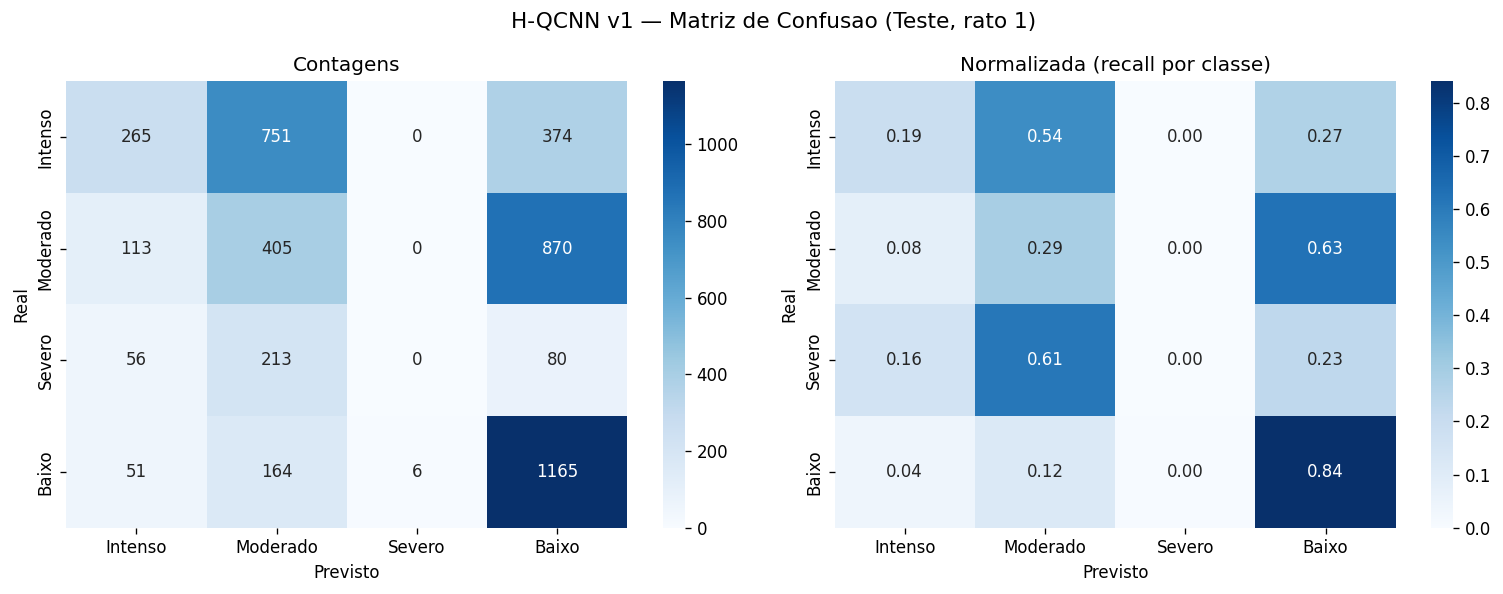

In [26]:
# ── Matriz de Confusão ────────────────────────────────────────────────────────
class_names    = full_train_aug.classes
class_names_pt = [LABEL_PT.get(c, c) for c in class_names]
cm      = confusion_matrix(y_true_test, y_pred_test)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_pt, yticklabels=class_names_pt, ax=axes[0])
axes[0].set_title('Contagens', fontsize=12)
axes[0].set_xlabel('Previsto')
axes[0].set_ylabel('Real')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names_pt, yticklabels=class_names_pt, ax=axes[1])
axes[1].set_title('Normalizada (recall por classe)', fontsize=12)
axes[1].set_xlabel('Previsto')
axes[1].set_ylabel('Real')

plt.suptitle('H-QCNN v1 — Matriz de Confusao (Teste, rato 1)', fontsize=13)
plt.tight_layout()
plt.savefig('v1_confusion_matrix.pdf', bbox_inches='tight')
plt.show()

Calculando SHAP values (pode levar alguns minutos)...
Amostras selecionadas: 4  (uma por classe)
shap_arr.shape: (4, 3, 224, 224, 4)  |  B=4
shap_importance.shape: (4, 224, 224)


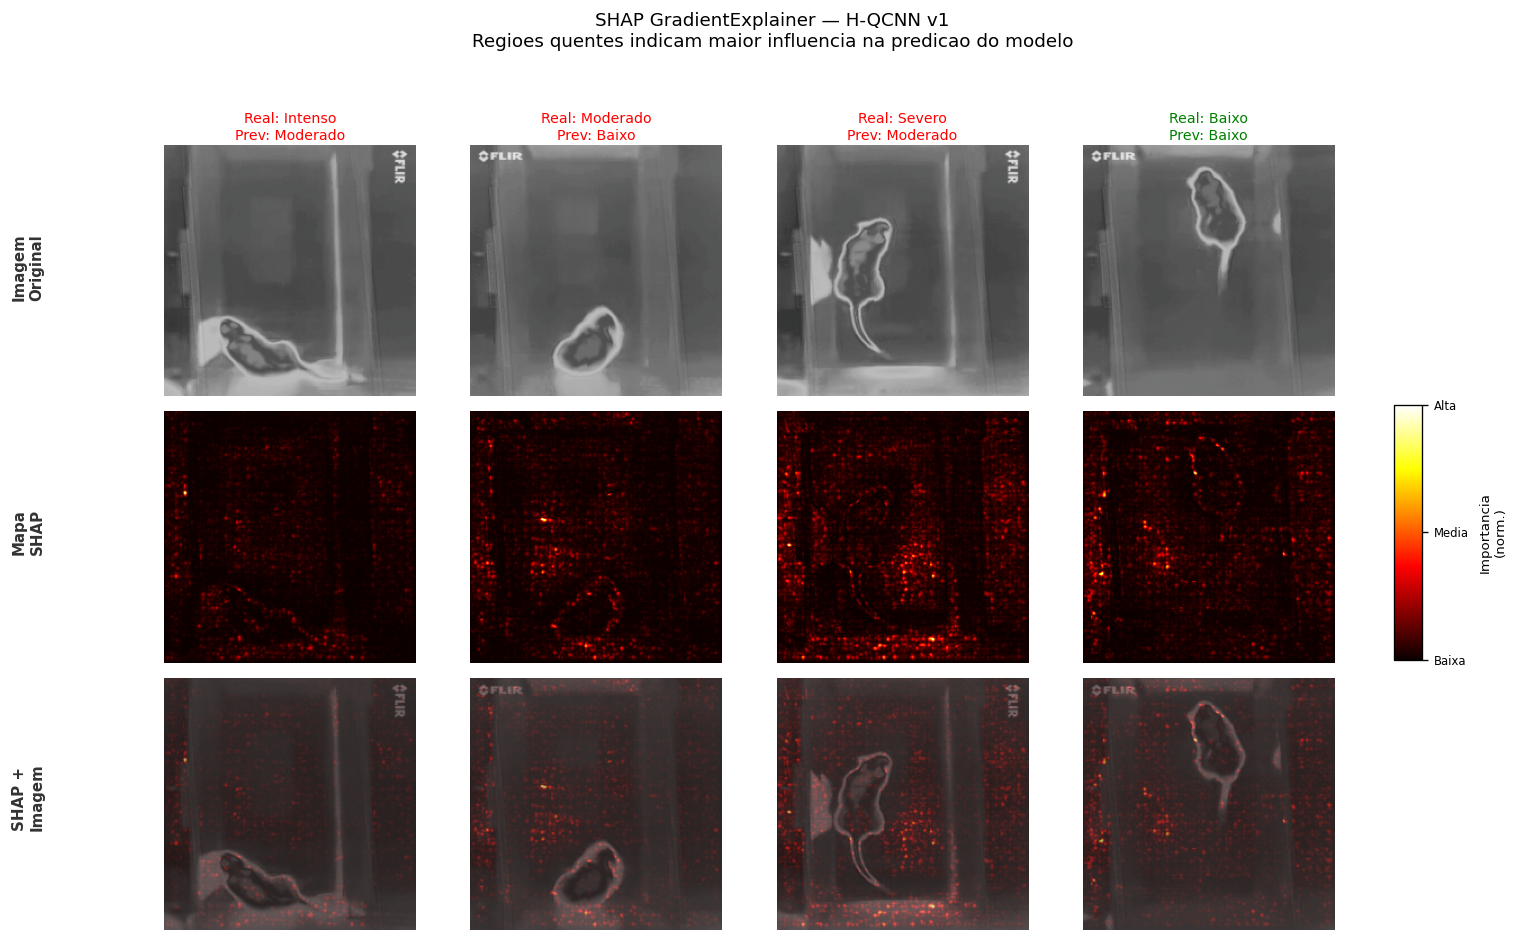

Salvo: v1_shap.pdf


In [25]:
# ── SHAP — GradientExplainer ──────────────────────────────────────────────────
print('Calculando SHAP values (pode levar alguns minutos)...')
model.eval()

# Background: 32 amostras aleatórias do treino (sem augmentation)
rng           = np.random.default_rng(SEED)
bg_idx_sample = rng.choice(len(train_idx), size=min(32, len(train_idx)), replace=False)
bg_subset     = Subset(full_train_eval, [train_idx[i] for i in bg_idx_sample])
bg_loader     = DataLoader(bg_subset, batch_size=32, shuffle=False)
bg_images, _  = next(iter(bg_loader))
bg_images     = bg_images.to(DEVICE)

# ── Seleciona UMA imagem por classe do conjunto de teste ─────────────────────
from collections import defaultdict
class_pool = defaultdict(list)
for idx, (_, label) in enumerate(test_dataset.imgs):
    class_pool[label].append(idx)

rng_sel = np.random.default_rng(SEED + 1)
selected_test_idx = [
    int(rng_sel.choice(class_pool[c])) for c in range(N_CLASSES)
]

exp_images = torch.stack([test_dataset[i][0] for i in selected_test_idx]).to(DEVICE)
exp_labels = torch.tensor([test_dataset[i][1] for i in selected_test_idx])
B_exp      = exp_images.size(0)
print(f'Amostras selecionadas: {B_exp}  (uma por classe)')

# SHAP values
explainer   = shap.GradientExplainer(model, bg_images)
shap_values = explainer.shap_values(exp_images)

# ── Normaliza para (B, H, W) — detecta formato automaticamente ───────────────
shap_arr = np.abs(np.array(shap_values))
print(f'shap_arr.shape: {shap_arr.shape}  |  B={B_exp}')

if shap_arr.ndim == 5 and shap_arr.shape[0] == B_exp:
    shap_importance = shap_arr.mean(axis=(1, 4))   # (B, C, H, W, N_CLASSES)
elif shap_arr.ndim == 5 and shap_arr.shape[1] == B_exp:
    shap_importance = shap_arr.mean(axis=(0, 2))   # (N_CLASSES, B, C, H, W)
elif shap_arr.ndim == 5 and shap_arr.shape[2] == B_exp:
    shap_importance = shap_arr.mean(axis=(0, 1))   # (N_CLASSES, C, B, H, W)
elif shap_arr.ndim == 4 and shap_arr.shape[0] == B_exp:
    shap_importance = shap_arr.mean(axis=1)         # (B, C, H, W)
else:
    raise ValueError(f'Formato SHAP nao mapeado: {shap_arr.shape}, B={B_exp}')

print(f'shap_importance.shape: {shap_importance.shape}')

# Desfaz normalização ImageNet
_mean  = np.array([0.485, 0.456, 0.406])
_std   = np.array([0.229, 0.224, 0.225])
exp_np = exp_images.cpu().numpy().transpose(0, 2, 3, 1)
exp_np = np.clip(exp_np * _std + _mean, 0, 1)

with torch.no_grad():
    preds_shap = model(exp_images).argmax(dim=1).cpu().numpy()

class_names = full_train_aug.classes

# ── Figura para dissertação: 3 linhas × N_CLASSES colunas ────────────────────
N_SHOW = N_CLASSES
fig, axes = plt.subplots(3, N_SHOW,
                          figsize=(3.2 * N_SHOW, 8.5),
                          gridspec_kw={'hspace': 0.06, 'wspace': 0.04})
fig.subplots_adjust(left=0.09, right=0.88)

for r in range(3):
    for c in range(N_SHOW):
        axes[r, c].axis('off')

ROW_LABELS = ['Imagem\nOriginal', 'Mapa\nSHAP', 'SHAP +\nImagem']

for col in range(N_SHOW):
    true_orig = class_names[exp_labels[col].item()]
    pred_orig = class_names[preds_shap[col]]
    true_lbl  = LABEL_PT.get(true_orig, true_orig)
    pred_lbl  = LABEL_PT.get(pred_orig, pred_orig)
    cor       = 'green' if true_orig == pred_orig else 'red'
    sm        = shap_importance[col]
    sm        = (sm - sm.min()) / (sm.max() - sm.min() + 1e-8)

    axes[0, col].imshow(exp_np[col])
    axes[0, col].set_title(f'Real: {true_lbl}\nPrev: {pred_lbl}',
                            fontsize=8.5, color=cor, pad=3)

    im = axes[1, col].imshow(sm, cmap='hot', vmin=0, vmax=1)

    axes[2, col].imshow(exp_np[col])
    axes[2, col].imshow(sm, cmap='hot', alpha=0.55)

# Labels das linhas
row_centers = [0.76, 0.50, 0.24]
for yc, lbl in zip(row_centers, ROW_LABELS):
    fig.text(0.005, yc, lbl, fontsize=9, va='center',
             ha='left', rotation=90, fontweight='bold', color='#333333')

# Colorbar
cbar_ax = fig.add_axes([0.905, 0.375, 0.018, 0.25])
cb = plt.colorbar(im, cax=cbar_ax)
cb.set_label('Importancia\n(norm.)', fontsize=8, labelpad=6)
cb.set_ticks([0, 0.5, 1])
cb.set_ticklabels(['Baixa', 'Media', 'Alta'], fontsize=7)

plt.suptitle('SHAP GradientExplainer — H-QCNN v1\n'
             'Regioes quentes indicam maior influencia na predicao do modelo',
             fontsize=11, y=1.01)
plt.savefig('v1_shap.pdf', bbox_inches='tight')
plt.show()
print('Salvo: v1_shap.pdf')